# Optimización de portafolio con acciones del IPSA

**Pregunta.** ¿Se puede construir un portafolio de acciones chilenas con mejor relación retorno-riesgo que el IPSA, y esa ventaja se mantiene fuera de muestra?

**Datos.** Precios diarios ajustados por dividendos de nueve acciones del IPSA y del ETF It Now IPSA como referencia de mercado, entre enero de 2019 y agosto de 2026. La tasa libre de riesgo es la Tasa de Política Monetaria (TPM) del Banco Central de Chile.

**Método.** Estadísticas de riesgo por activo, regresión CAPM, frontera eficiente de Markowitz sin ventas cortas y un backtest fuera de muestra con rebalanceo trimestral y costos de transacción.

**Resultado principal.** Dentro de muestra la optimización luce muy superior al índice, pero esa comparación es engañosa porque usa información futura. En el backtest honesto, las tres estrategias diversificadas superan al ETF IPSA en el período 2021 a 2026. Sin embargo, la ventaja del portafolio de máximo Sharpe sobre la cartera de pesos iguales no es estadísticamente significativa con cinco años de datos.

## 1. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dsaplicado import datos, portafolio as pf
from dsaplicado.graficos import (
    AZUL_SECUENCIAL, COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo, eje_porcentaje,
    separar_etiquetas,
)
from matplotlib.ticker import NullFormatter, ScalarFormatter

# Desplazamientos de etiqueta para puntos que quedan muy cerca entre sí.
DESPLAZAMIENTO = {"Banco de Chile": (-6, 4, "right"), "BCI": (6, 4, "left")}

aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)

RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "02_finanzas" / "figuras"
FIGURAS.mkdir(exist_ok=True)

INICIO, FIN = "2019-01-01", "2026-09-01"   # FIN no se incluye
TOPE_POR_ACTIVO = 0.30                     # límite de concentración por acción
COSTO_TRANSACCION = 0.002                  # 20 puntos base por unidad transada

## 2. Datos

Los precios se descargan desde Yahoo Finance y quedan guardados en `datos/`. Así el notebook entrega los mismos resultados en cada ejecución. Para actualizar los datos basta con pasar `actualizar=True`.

Se excluye LATAM Airlines porque su quiebra y reestructuración entre 2020 y 2022 distorsiona cualquier estimación de retorno y covarianza.

In [2]:
precios = datos.cargar_precios(
    RAIZ / "datos" / "precios_ipsa.csv",
    {**datos.ACCIONES_IPSA, **datos.BENCHMARK_IPSA},
    INICIO, FIN,
)
tpm = datos.cargar_indicador(RAIZ / "datos" / "tpm.csv", "tpm", range(2019, 2027))

print(f"Período: {precios.index.min():%d-%m-%Y} a {precios.index.max():%d-%m-%Y}, {len(precios)} días hábiles")
print("Valores faltantes por serie:")
print(precios.isna().sum()[lambda s: s > 0])

Período: 02-01-2019 a 31-08-2026, 1909 días hábiles
Valores faltantes por serie:
ETF IPSA    1
dtype: int64


### Control de calidad

- **Precio faltante del ETF.** Hay un solo día sin precio. Se completa con el último valor conocido, que equivale a suponer retorno cero ese día.
- **Error en la TPM.** La fuente reporta una TPM de 0% el 20 de julio de 2020. La TPM nunca bajó de 0,5% en ese período, así que se trata como dato erróneo y se reemplaza por el valor anterior.

In [3]:
print("Registros de TPM bajo el mínimo histórico de 0,5%:")
print(tpm[tpm < 0.5])

precios = precios.ffill()
tpm = tpm.mask(tpm < 0.5).ffill().loc[:precios.index.max()] / 100
rf_anual = tpm.mean()
rf_diario = (1 + tpm) ** (1 / pf.DIAS_HABILES) - 1
print(f"\nTPM promedio del período, usada como tasa libre de riesgo: {rf_anual:.2%}")

Registros de TPM bajo el mínimo histórico de 0,5%:
fecha
2020-07-20   0.000
Name: tpm, dtype: float64

TPM promedio del período, usada como tasa libre de riesgo: 4.90%


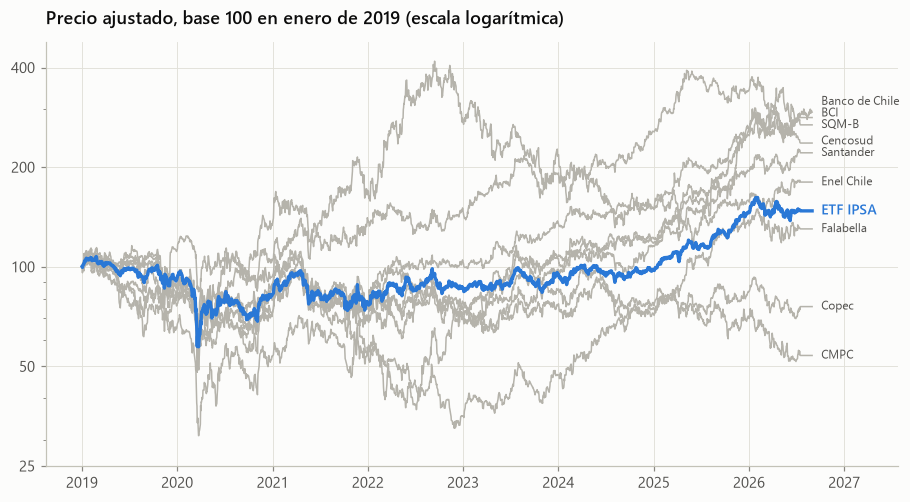

In [4]:
base_100 = precios / precios.iloc[0] * 100
acciones = list(datos.ACCIONES_IPSA.values())

fig, ax = plt.subplots(figsize=(10, 5))
for nombre in acciones:
    ax.plot(base_100.index, base_100[nombre], color=NEUTRO, linewidth=1)
ax.plot(base_100.index, base_100["ETF IPSA"], color=COLORES[0], linewidth=2.2)

# Etiquetas directas al final de cada serie, separadas en escala logarítmica.
finales = {n: np.log10(base_100[n].iloc[-1]) for n in acciones + ["ETF IPSA"]}
for nombre, pos in separar_etiquetas(finales, 0.035).items():
    es_indice = nombre == "ETF IPSA"
    ax.annotate(nombre, (base_100.index[-1], 10 ** pos), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9 if es_indice else 8, weight="semibold" if es_indice else "normal",
                color=COLORES[0] if es_indice else TINTA_SECUNDARIA)
ax.set_yscale("log")
ax.set_yticks([25, 50, 100, 200, 400])
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_title("Precio ajustado, base 100 en enero de 2019 (escala logarítmica)")
ax.set_xlim(right=base_100.index[-1] + pd.Timedelta(days=330))
plt.show()

La dispersión entre acciones es enorme. SQM y los bancos más que duplicaron su valor, mientras CMPC y Copec terminan cerca o bajo su precio inicial. Esa dispersión es la materia prima de la optimización, y también su principal riesgo, porque premia a las acciones que ya subieron.

## 3. Retorno y riesgo por activo

Se usan retornos simples, porque el retorno de un portafolio es el promedio ponderado de los retornos simples de sus activos.

In [5]:
retornos = pf.retornos_simples(precios).dropna()
activos = retornos[acciones]
mercado = retornos["ETF IPSA"]

resumen = pf.estadisticas_anualizadas(retornos, rf_anual).sort_values("sharpe", ascending=False)
resumen

,retorno_anual,volatilidad_anual,sharpe
Banco de Chile,0.178,0.270,0.480
BCI,0.181,0.296,0.446
SQM-B,0.230,0.447,0.405
Cencosud,0.167,0.326,0.361
Santander,0.143,0.275,0.341
Enel Chile,0.126,0.309,0.248
Falabella,0.092,0.337,0.126
ETF IPSA,0.075,0.216,0.119
Copec,0.013,0.316,-0.113
CMPC,-0.024,0.339,-0.215


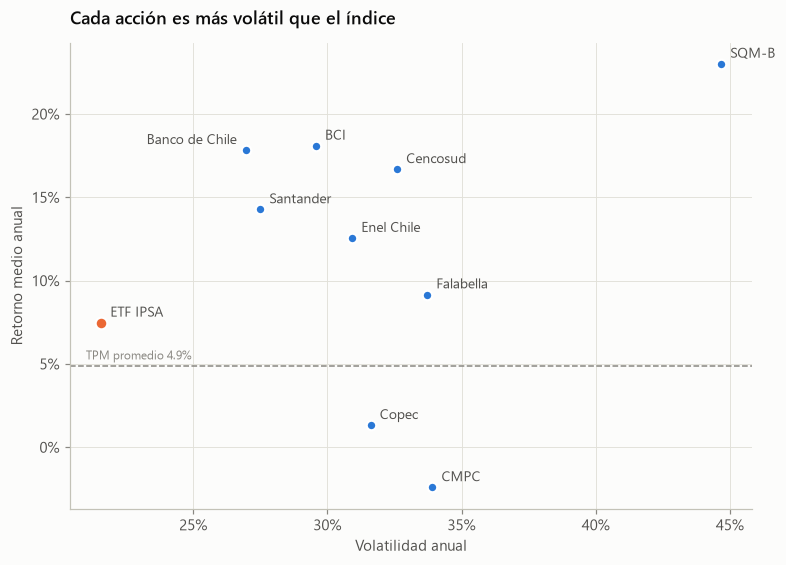

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for nombre, fila in resumen.iterrows():
    es_indice = nombre == "ETF IPSA"
    ax.scatter(fila["volatilidad_anual"], fila["retorno_anual"], s=60 if es_indice else 40,
               color=COLORES[1] if es_indice else COLORES[0], edgecolor="white", linewidth=1.5, zorder=3)
    dx, dy, alineacion = DESPLAZAMIENTO.get(nombre, (6, 4, "left"))
    ax.annotate(nombre, (fila["volatilidad_anual"], fila["retorno_anual"]), xytext=(dx, dy), ha=alineacion,
                textcoords="offset points", fontsize=9, color=TINTA_SECUNDARIA)
ax.axhline(rf_anual, color=TINTA_TENUE, linewidth=1, linestyle="--")
ax.annotate(f"TPM promedio {rf_anual:.1%}", (0.21, rf_anual), xytext=(0, 4), textcoords="offset points",
            fontsize=8, color=TINTA_TENUE)
eje_porcentaje(ax, "x"); eje_porcentaje(ax, "y")
ax.set_xlabel("Volatilidad anual"); ax.set_ylabel("Retorno medio anual")
ax.set_title("Cada acción es más volátil que el índice")
plt.show()

Todas las acciones son más volátiles que el ETF IPSA. Ninguna combina menor riesgo con mayor retorno que el índice, así que cualquier mejora tiene que venir de la diversificación y no de elegir una sola acción.

## 4. Correlaciones

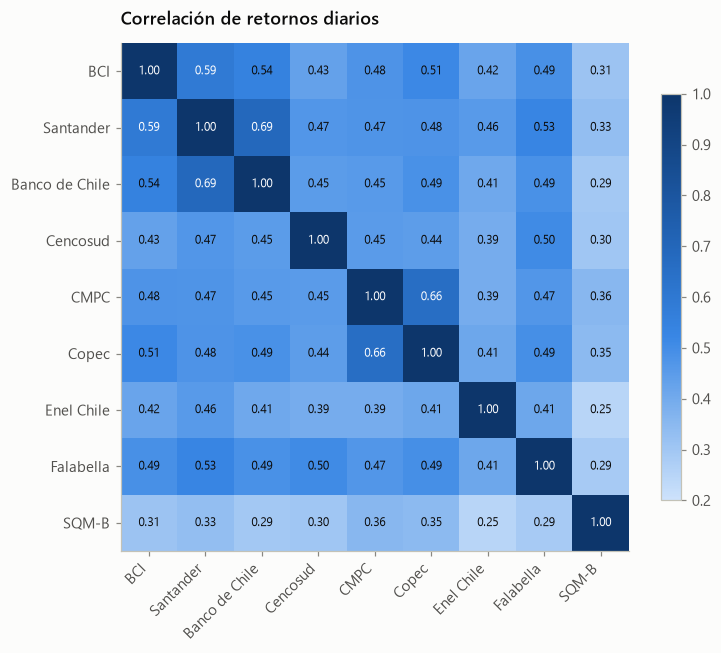

Correlación promedio entre pares: 0.44
Par más correlacionado: ('Santander', 'Banco de Chile') con 0.69
Par menos correlacionado: ('Enel Chile', 'SQM-B') con 0.25


In [7]:
corr = activos.corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(corr, cmap=AZUL_SECUENCIAL, vmin=0.2, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        valor = corr.iloc[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8,
                color="white" if valor > 0.55 else "#0b0b0b")
ax.grid(False)
ax.set_title("Correlación de retornos diarios")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

triangulo = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print(f"Correlación promedio entre pares: {triangulo.mean():.2f}")
print(f"Par más correlacionado: {triangulo.idxmax()} con {triangulo.max():.2f}")
print(f"Par menos correlacionado: {triangulo.idxmin()} con {triangulo.min():.2f}")

Los tres bancos forman el bloque más correlacionado, porque responden a los mismos factores: tasas, crecimiento y riesgo de crédito local. SQM es la acción menos correlacionada con el resto, porque depende del precio global del litio más que de la economía chilena. Por eso SQM aporta diversificación aunque sea la acción más volátil.

## 5. CAPM: exposición al mercado

Se estima la regresión de excesos de retorno sobre la TPM diaria:

$$r_i - r_f = \alpha_i + \beta_i \,(r_m - r_f) + \varepsilon_i$$

In [8]:
capm = pf.beta_capm(activos, mercado, rf_diario).sort_values("beta")
capm

,alfa_anual,beta,r2
Enel Chile,0.059,0.685,0.228
BCI,0.112,0.787,0.330
Banco de Chile,0.109,0.791,0.400
Santander,0.073,0.822,0.416
Cencosud,0.097,0.824,0.297
Copec,-0.057,0.853,0.339
CMPC,-0.095,0.876,0.310
Falabella,0.019,0.941,0.363
SQM-B,0.150,1.191,0.331


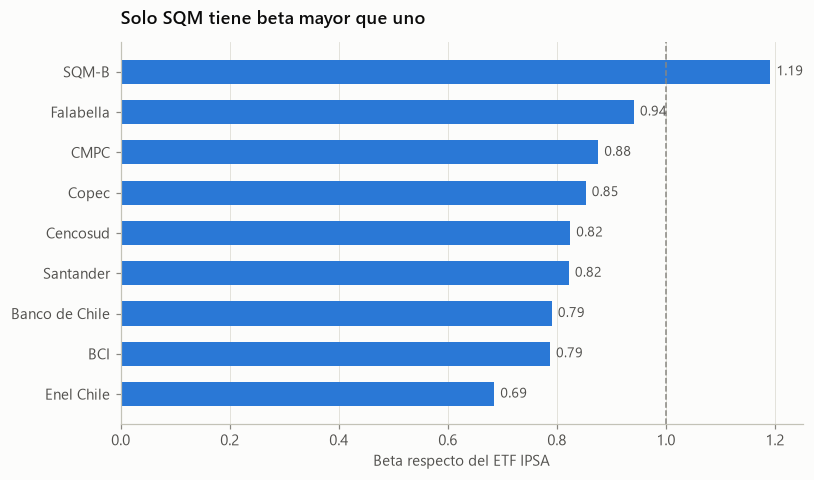

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(capm.index, capm["beta"], color=COLORES[0], height=0.6)
ax.axvline(1, color=TINTA_TENUE, linewidth=1, linestyle="--")
for i, (nombre, beta) in enumerate(capm["beta"].items()):
    ax.annotate(f"{beta:.2f}", (beta, i), xytext=(4, 0), textcoords="offset points", va="center",
                fontsize=9, color=TINTA_SECUNDARIA)
ax.set_xlabel("Beta respecto del ETF IPSA")
ax.set_title("Solo SQM tiene beta mayor que uno")
ax.grid(axis="y", visible=False)
plt.show()

**Lectura.** Las betas son menores que uno porque el índice diversifica parte del riesgo específico de cada acción. El R cuadrado de entre 0,23 y 0,42 confirma que la mayor parte de la varianza de cada acción es idiosincrática, que es justamente el riesgo que la diversificación elimina.

Los alfas anuales positivos de los bancos y SQM describen lo que ocurrió en el período, no lo que se puede esperar. Un alfa estimado con siete años de datos tiene un error estándar muy amplio.

## 6. Frontera eficiente dentro de muestra

Se estiman retornos esperados y covarianzas con todo el período. Se imponen dos restricciones realistas: sin ventas cortas y máximo 30% por acción.

In [10]:
mu = activos.mean() * pf.DIAS_HABILES
cov = activos.cov() * pf.DIAS_HABILES

w_minvar = pf.minima_varianza(cov.values, TOPE_POR_ACTIVO)
w_sharpe = pf.maximo_sharpe(mu.values, cov.values, rf_anual, TOPE_POR_ACTIVO)
w_iguales = np.full(len(acciones), 1 / len(acciones))
frontera = pf.frontera_eficiente(mu.values, cov.values, n_puntos=50, cota_max=TOPE_POR_ACTIVO)
simulados = pf.simular_portafolios(mu.values, cov.values, n=20_000, rf=rf_anual)

carteras = {"Mínima varianza": w_minvar, "Máximo Sharpe": w_sharpe, "Pesos iguales": w_iguales}
tabla = pd.DataFrame(
    {nombre: dict(zip(["retorno", "volatilidad"], pf.rendimiento_portafolio(w, mu, cov))) for nombre, w in carteras.items()}
).T
tabla["sharpe"] = (tabla["retorno"] - rf_anual) / tabla["volatilidad"]
tabla

,retorno,volatilidad,sharpe
Mínima varianza,0.144,0.221,0.432
Máximo Sharpe,0.190,0.242,0.581
Pesos iguales,0.123,0.228,0.324


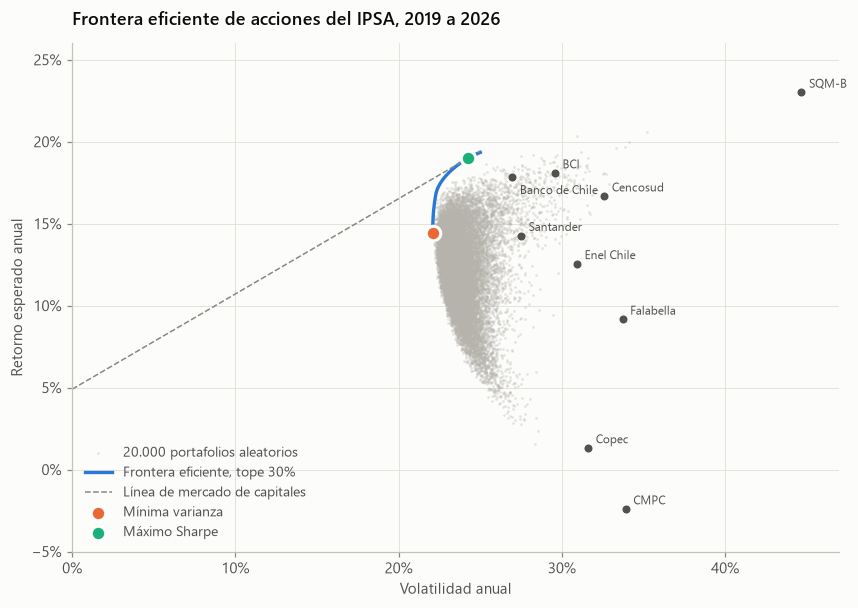

In [11]:
ret_ms, vol_ms = pf.rendimiento_portafolio(w_sharpe, mu, cov)
ret_mv, vol_mv = pf.rendimiento_portafolio(w_minvar, mu, cov)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(simulados["volatilidad"], simulados["retorno"], s=3, color=NEUTRO, alpha=0.35, linewidths=0,
           label="20.000 portafolios aleatorios")
ax.plot(frontera["volatilidad"], frontera["retorno"], color=COLORES[0], linewidth=2.2,
        label="Frontera eficiente, tope 30%")
vols = np.linspace(0, frontera["volatilidad"].max(), 50)
ax.plot(vols, rf_anual + (ret_ms - rf_anual) / vol_ms * vols, color=TINTA_TENUE, linewidth=1, linestyle="--",
        label="Línea de mercado de capitales")
for (vol, ret), color, nombre in [((vol_mv, ret_mv), COLORES[1], "Mínima varianza"),
                                  ((vol_ms, ret_ms), COLORES[2], "Máximo Sharpe")]:
    ax.scatter(vol, ret, s=90, color=color, edgecolor="white", linewidth=2, zorder=4, label=nombre)
for nombre, fila in resumen.drop("ETF IPSA").iterrows():
    ax.scatter(fila["volatilidad_anual"], fila["retorno_anual"], s=18, color=TINTA_SECUNDARIA, zorder=3)
    dx, dy, alineacion = {"Banco de Chile": (5, -11, "left")}.get(nombre, (5, 3, "left"))
    ax.annotate(nombre, (fila["volatilidad_anual"], fila["retorno_anual"]), xytext=(dx, dy), ha=alineacion,
                textcoords="offset points", fontsize=8, color=TINTA_SECUNDARIA)
ax.set_xlim(0, 0.47); ax.set_ylim(-0.05, 0.26)
eje_porcentaje(ax, "x"); eje_porcentaje(ax, "y")
ax.set_xlabel("Volatilidad anual"); ax.set_ylabel("Retorno esperado anual")
ax.set_title("Frontera eficiente de acciones del IPSA, 2019 a 2026")
ax.legend(loc="lower left", fontsize=9)
fig.savefig(FIGURAS / "frontera_eficiente.png", bbox_inches="tight")
plt.show()

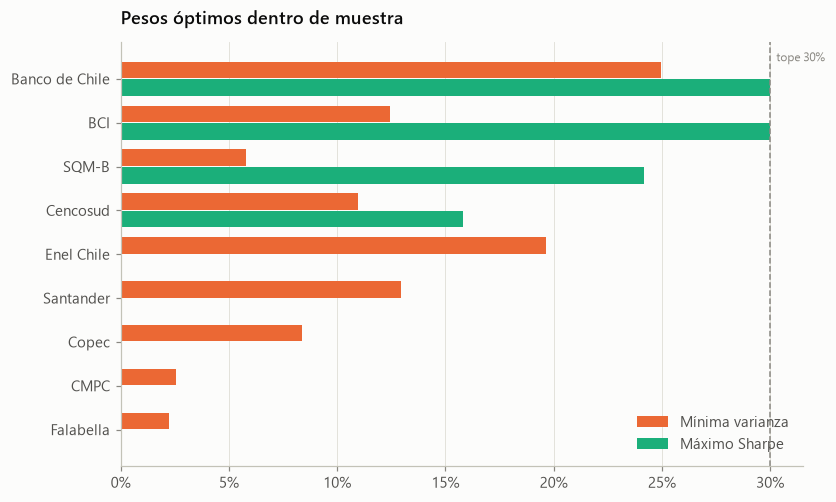

In [12]:
pesos = pd.DataFrame({"Mínima varianza": w_minvar, "Máximo Sharpe": w_sharpe}, index=acciones)
orden = pesos.sum(axis=1).sort_values().index
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(orden))
ax.barh(y + 0.2, pesos.loc[orden, "Mínima varianza"], height=0.38, color=COLORES[1], label="Mínima varianza")
ax.barh(y - 0.2, pesos.loc[orden, "Máximo Sharpe"], height=0.38, color=COLORES[2], label="Máximo Sharpe")
ax.set_yticks(y, orden)
ax.axvline(TOPE_POR_ACTIVO, color=TINTA_TENUE, linewidth=1, linestyle="--")
ax.annotate("tope 30%", (TOPE_POR_ACTIVO, len(orden) - 0.6), xytext=(4, 0), textcoords="offset points",
            fontsize=8, color=TINTA_TENUE)
eje_porcentaje(ax, "x")
ax.grid(axis="y", visible=False)
ax.set_title("Pesos óptimos dentro de muestra")
ax.legend(loc="lower right")
plt.show()

**Lectura.**

- **Mínima varianza.** Reparte el peso entre casi todas las acciones y favorece a las de menor volatilidad y menor correlación, como Banco de Chile y Enel Chile. No usa el retorno esperado, lo que la hace más estable.
- **Máximo Sharpe.** Concentra todo en cuatro acciones, las que mejor rindieron en el período. El tope de 30% se activa en dos de ellas. Esta concentración es la señal típica de que el optimizador está sobreajustando los retornos pasados.

Todo lo anterior es un ejercicio dentro de muestra: se eligieron los pesos conociendo los retornos que se usan para evaluarlos. Para saber si la optimización agrega valor hay que evaluarla fuera de muestra.

## 7. Backtest fuera de muestra

Reglas del backtest:

1. Al cierre de cada trimestre, cada estrategia estima sus pesos usando solo los dos años anteriores.
2. Los pesos se mantienen hasta el siguiente trimestre y derivan con los precios, como en un portafolio real.
3. Cada rebalanceo paga 20 puntos base por unidad transada.
4. La referencia es el ETF IPSA, que es una alternativa invertible real.

El backtest parte en abril de 2021, cuando se acumulan dos años de historia.

In [13]:
def pesos_iguales(ventana):
    return np.full(ventana.shape[1], 1 / ventana.shape[1])

def minima_varianza(ventana):
    return pf.minima_varianza((ventana.cov() * pf.DIAS_HABILES).values, TOPE_POR_ACTIVO)

def maximo_sharpe(ventana):
    rf = float(tpm.loc[:ventana.index[-1]].iloc[-1])  # TPM vigente al momento de decidir
    return pf.maximo_sharpe((ventana.mean() * pf.DIAS_HABILES).values,
                            (ventana.cov() * pf.DIAS_HABILES).values, rf, TOPE_POR_ACTIVO)

estrategias = {"Pesos iguales": pesos_iguales, "Mínima varianza": minima_varianza, "Máximo Sharpe": maximo_sharpe}
resultados, historiales = {}, {}
for nombre, funcion in estrategias.items():
    resultados[nombre], historiales[nombre] = pf.backtest_rebalanceo(
        activos, funcion, ventana=504, frecuencia="QE", costo=COSTO_TRANSACCION)

fechas_bt = resultados["Pesos iguales"].index
resultados["ETF IPSA"] = mercado.loc[fechas_bt]
rf_bt = tpm.loc[fechas_bt[0]:].mean()
print(f"Backtest: {fechas_bt[0]:%d-%m-%Y} a {fechas_bt[-1]:%d-%m-%Y}, TPM promedio {rf_bt:.2%}")

metricas = pd.DataFrame({n: pf.metricas_desempeno(r, rf_bt) for n, r in resultados.items()}).T
metricas["rotacion_anual"] = pd.Series(
    {n: h["rotacion"].iloc[1:].mean() * 4 for n, h in historiales.items()})
metricas

Backtest: 01-04-2021 a 31-08-2026, TPM promedio 6.32%


,retorno_anual,volatilidad_anual,sharpe,max_drawdown,rotacion_anual
Pesos iguales,0.122,0.197,0.296,-0.242,0.322
Mínima varianza,0.164,0.195,0.518,-0.277,0.775
Máximo Sharpe,0.203,0.221,0.632,-0.218,1.302
ETF IPSA,0.085,0.191,0.115,-0.242,NaN


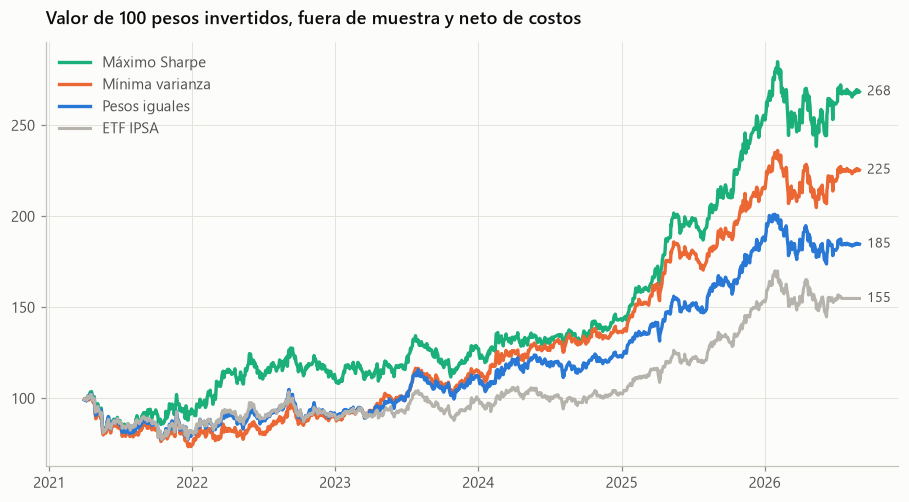

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
estilos = {"Máximo Sharpe": COLORES[2], "Mínima varianza": COLORES[1], "Pesos iguales": COLORES[0], "ETF IPSA": NEUTRO}
for nombre, color in estilos.items():
    valor = 100 * (1 + resultados[nombre]).cumprod()
    ax.plot(valor.index, valor, color=color, linewidth=2.2 if nombre != "ETF IPSA" else 2, label=nombre)
    ax.annotate(f"{valor.iloc[-1]:.0f}", (valor.index[-1], valor.iloc[-1]), xytext=(5, 0),
                textcoords="offset points", va="center", fontsize=9, color=TINTA_SECUNDARIA)
ax.set_title("Valor de 100 pesos invertidos, fuera de muestra y neto de costos")
ax.legend(loc="upper left")
fig.savefig(FIGURAS / "backtest_portafolios.png", bbox_inches="tight")
plt.show()

### ¿Es significativa la diferencia de Sharpe?

Con retornos aproximadamente independientes, el error estándar del índice de Sharpe anual es cercano a $\sqrt{(1 + SR^2/2)/T}$, donde $T$ es el número de años (Lo, 2002).

In [15]:
anios = len(fechas_bt) / pf.DIAS_HABILES
metricas["error_estandar_sharpe"] = np.sqrt((1 + metricas["sharpe"] ** 2 / 2) / anios)
metricas["ic95_inferior"] = metricas["sharpe"] - 1.96 * metricas["error_estandar_sharpe"]
metricas["ic95_superior"] = metricas["sharpe"] + 1.96 * metricas["error_estandar_sharpe"]
metricas[["sharpe", "error_estandar_sharpe", "ic95_inferior", "ic95_superior"]]

,sharpe,error_estandar_sharpe,ic95_inferior,ic95_superior
Pesos iguales,0.296,0.442,-0.570,1.163
Mínima varianza,0.518,0.461,-0.385,1.420
Máximo Sharpe,0.632,0.474,-0.297,1.560
ETF IPSA,0.115,0.434,-0.735,0.966


## 8. Conclusiones

1. **Las tres estrategias superaron al índice en este período.** Terminan con más riqueza que el ETF IPSA y con una volatilidad similar. Parte de esa ventaja se explica por el sesgo de supervivencia descrito en las limitaciones, así que la cifra exacta no debe leerse como un exceso de retorno esperable.
2. **La optimización dentro de muestra exagera los beneficios.** Los retornos esperados que muestra la frontera no son alcanzables, porque se calcularon sabiendo qué acciones iban a subir.
3. **Máximo Sharpe fue la mejor estrategia del período, pero no se puede afirmar que sea mejor.** Los intervalos de confianza de los cuatro índices de Sharpe se superponen ampliamente. Cinco años de datos no alcanzan para separar habilidad de suerte.
4. **Mínima varianza es la alternativa más defendible para usar en la práctica.** No depende de estimar retornos, que es la parte más ruidosa de Markowitz, y rota bastante menos que máximo Sharpe. Su costo fue una caída máxima algo mayor en este período, porque concentró peso en acciones que cayeron juntas en 2021 y 2022.

## 9. Limitaciones y próximos pasos

- **Sesgo de supervivencia.** Las nueve acciones se eligieron porque hoy pertenecen al IPSA y tienen historia completa. Excluir a LATAM, que perdió casi todo su valor, favorece a las estrategias frente al índice.
- **Universo pequeño.** Con nueve acciones la frontera tiene poco espacio para diversificar. Un universo más amplio exigiría estimadores de covarianza con contracción, como Ledoit-Wolf.
- **Referencia imperfecta.** El ETF IPSA cobra comisión de administración y puede tratar los dividendos de forma distinta a los precios ajustados de las acciones.
- **Próximo paso.** El notebook [02 de métricas de riesgo](02_metricas_de_riesgo.ipynb) mide el riesgo de cola de estas carteras con VaR y Expected Shortfall.